# Notebook 85 — raw Hough aggregation alternatives

This notebook keeps the same Python raw Hough candidate sets fixed and tests notebook-only alternatives to the current weighted-median raw alpha rule before any code patch.

In [1]:
from pathlib import Path
import subprocess
import sys
from IPython.display import Markdown, Image, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'scripts').exists():
    ROOT = ROOT.parent
SCRIPT = ROOT / 'scripts' / 'evaluate_raw_hough_aggregation_alternatives.py'
OUT = ROOT / 'results' / 'notebook85_raw_hough_aggregation_alternatives'
print(f'Project root: {ROOT}')
print(f'Script: {SCRIPT}')
print(f'Output directory: {OUT}')

Project root: /Users/grosbedou/PycharmProjects/NDORMS
Script: /Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_raw_hough_aggregation_alternatives.py
Output directory: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook85_raw_hough_aggregation_alternatives


In [3]:
completed = subprocess.run([sys.executable, str(SCRIPT)], check=True)
completed

Recomputing full-sequence TimTrack candidate sets with the baseline raw chain...
TimTrack image geofeatures processed 300
TimTrack image geofeatures processed 600
TimTrack image geofeatures processed 900
TimTrack image geofeatures processed 1200
TimTrack image geofeatures processed 1500
TimTrack image geofeatures processed 1800
TimTrack image geofeatures processed 2100
TimTrack image geofeatures processed 2400
Evaluating aggregation variant: weighted_median_current
Evaluating aggregation variant: weighted_mean
Evaluating aggregation variant: weighted_q25
Evaluating aggregation variant: weighted_q30
Evaluating aggregation variant: top_peak
# Notebook 85 — raw Hough aggregation alternatives

Recomputed the full baseline TimTrack candidate stream for 2666 aligned frames, then held those candidate sets fixed while swapping only the raw Hough aggregation rule.

This notebook does not patch production code. It asks whether a different raw aggregation rule improves parity on the same candidat

CompletedProcess(args=['/Library/Developer/CommandLineTools/usr/bin/python3', '/Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_raw_hough_aggregation_alternatives.py'], returncode=0)

In [4]:
display(Markdown((OUT / 'notebook85_summary.md').read_text()))

# Notebook 85 — raw Hough aggregation alternatives

Recomputed the full baseline TimTrack candidate stream for 2666 aligned frames, then held those candidate sets fixed while swapping only the raw Hough aggregation rule.

This notebook does not patch production code. It asks whether a different raw aggregation rule improves parity on the same candidate sets, or merely compensates for upstream candidate bias.

## Raw aggregation findings

- The current weighted-median rule reproduces the saved Python raw alpha exactly (raw-vs-saved RMSE 0.000000 deg), so it is the correct baseline.
- On the same candidate sets, the best raw-alpha RMSE against MATLAB geofeature alpha is `weighted_median_current` at 2.8086 deg, versus 2.8086 deg for the current weighted median.
- The best downstream FL RMSE after the same persistence and Kalman path is `weighted_mean` at 1.2649 mm, versus 2.0116 mm for the current weighted median.

## Interpretation

- If a non-MATLAB aggregation rule improves raw alpha and downstream FL on the same candidate sets, that does not prove MATLAB's aggregation is wrong.
- It means the current Python candidate distribution is biased enough that a different aggregator can partially compensate for upstream errors.
- So any future code patch here would be a modeling change, not a pure parity fix, unless we also show the candidate-generation side is already correct.
- This notebook therefore helps rank ideas, but it is not by itself a green light to change the production aggregation rule.

- Raw metrics CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook85_raw_hough_aggregation_alternatives/aggregation_raw_metrics.csv`
- Persistence metrics CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook85_raw_hough_aggregation_alternatives/aggregation_persistence_metrics.csv`
- Downstream metrics CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook85_raw_hough_aggregation_alternatives/aggregation_downstream_metrics.csv`
- Combined summary CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook85_raw_hough_aggregation_alternatives/aggregation_full_summary.csv`
- Per-frame CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook85_raw_hough_aggregation_alternatives/aggregation_per_frame.csv`
- Summary plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook85_raw_hough_aggregation_alternatives/aggregation_alternative_summary.png`
- Trace plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook85_raw_hough_aggregation_alternatives/aggregation_alternative_traces.png`


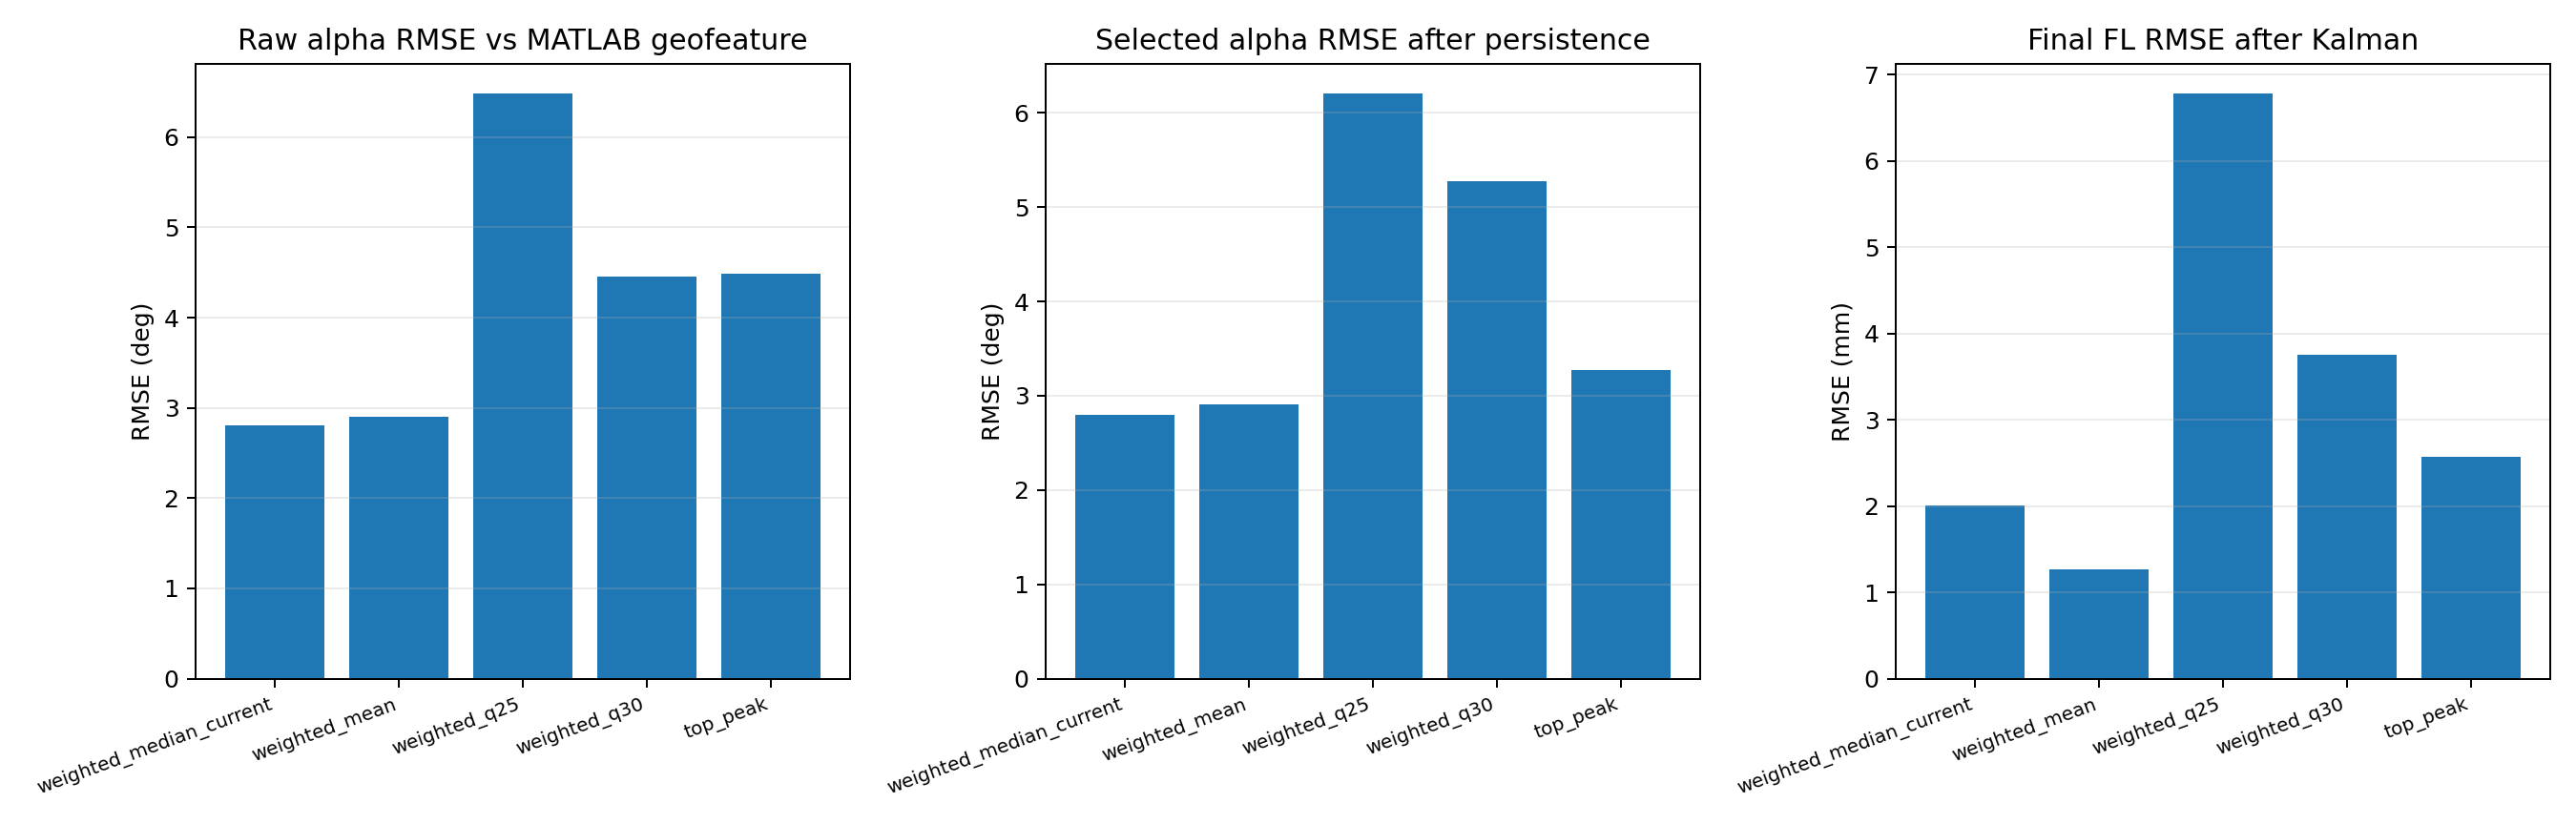

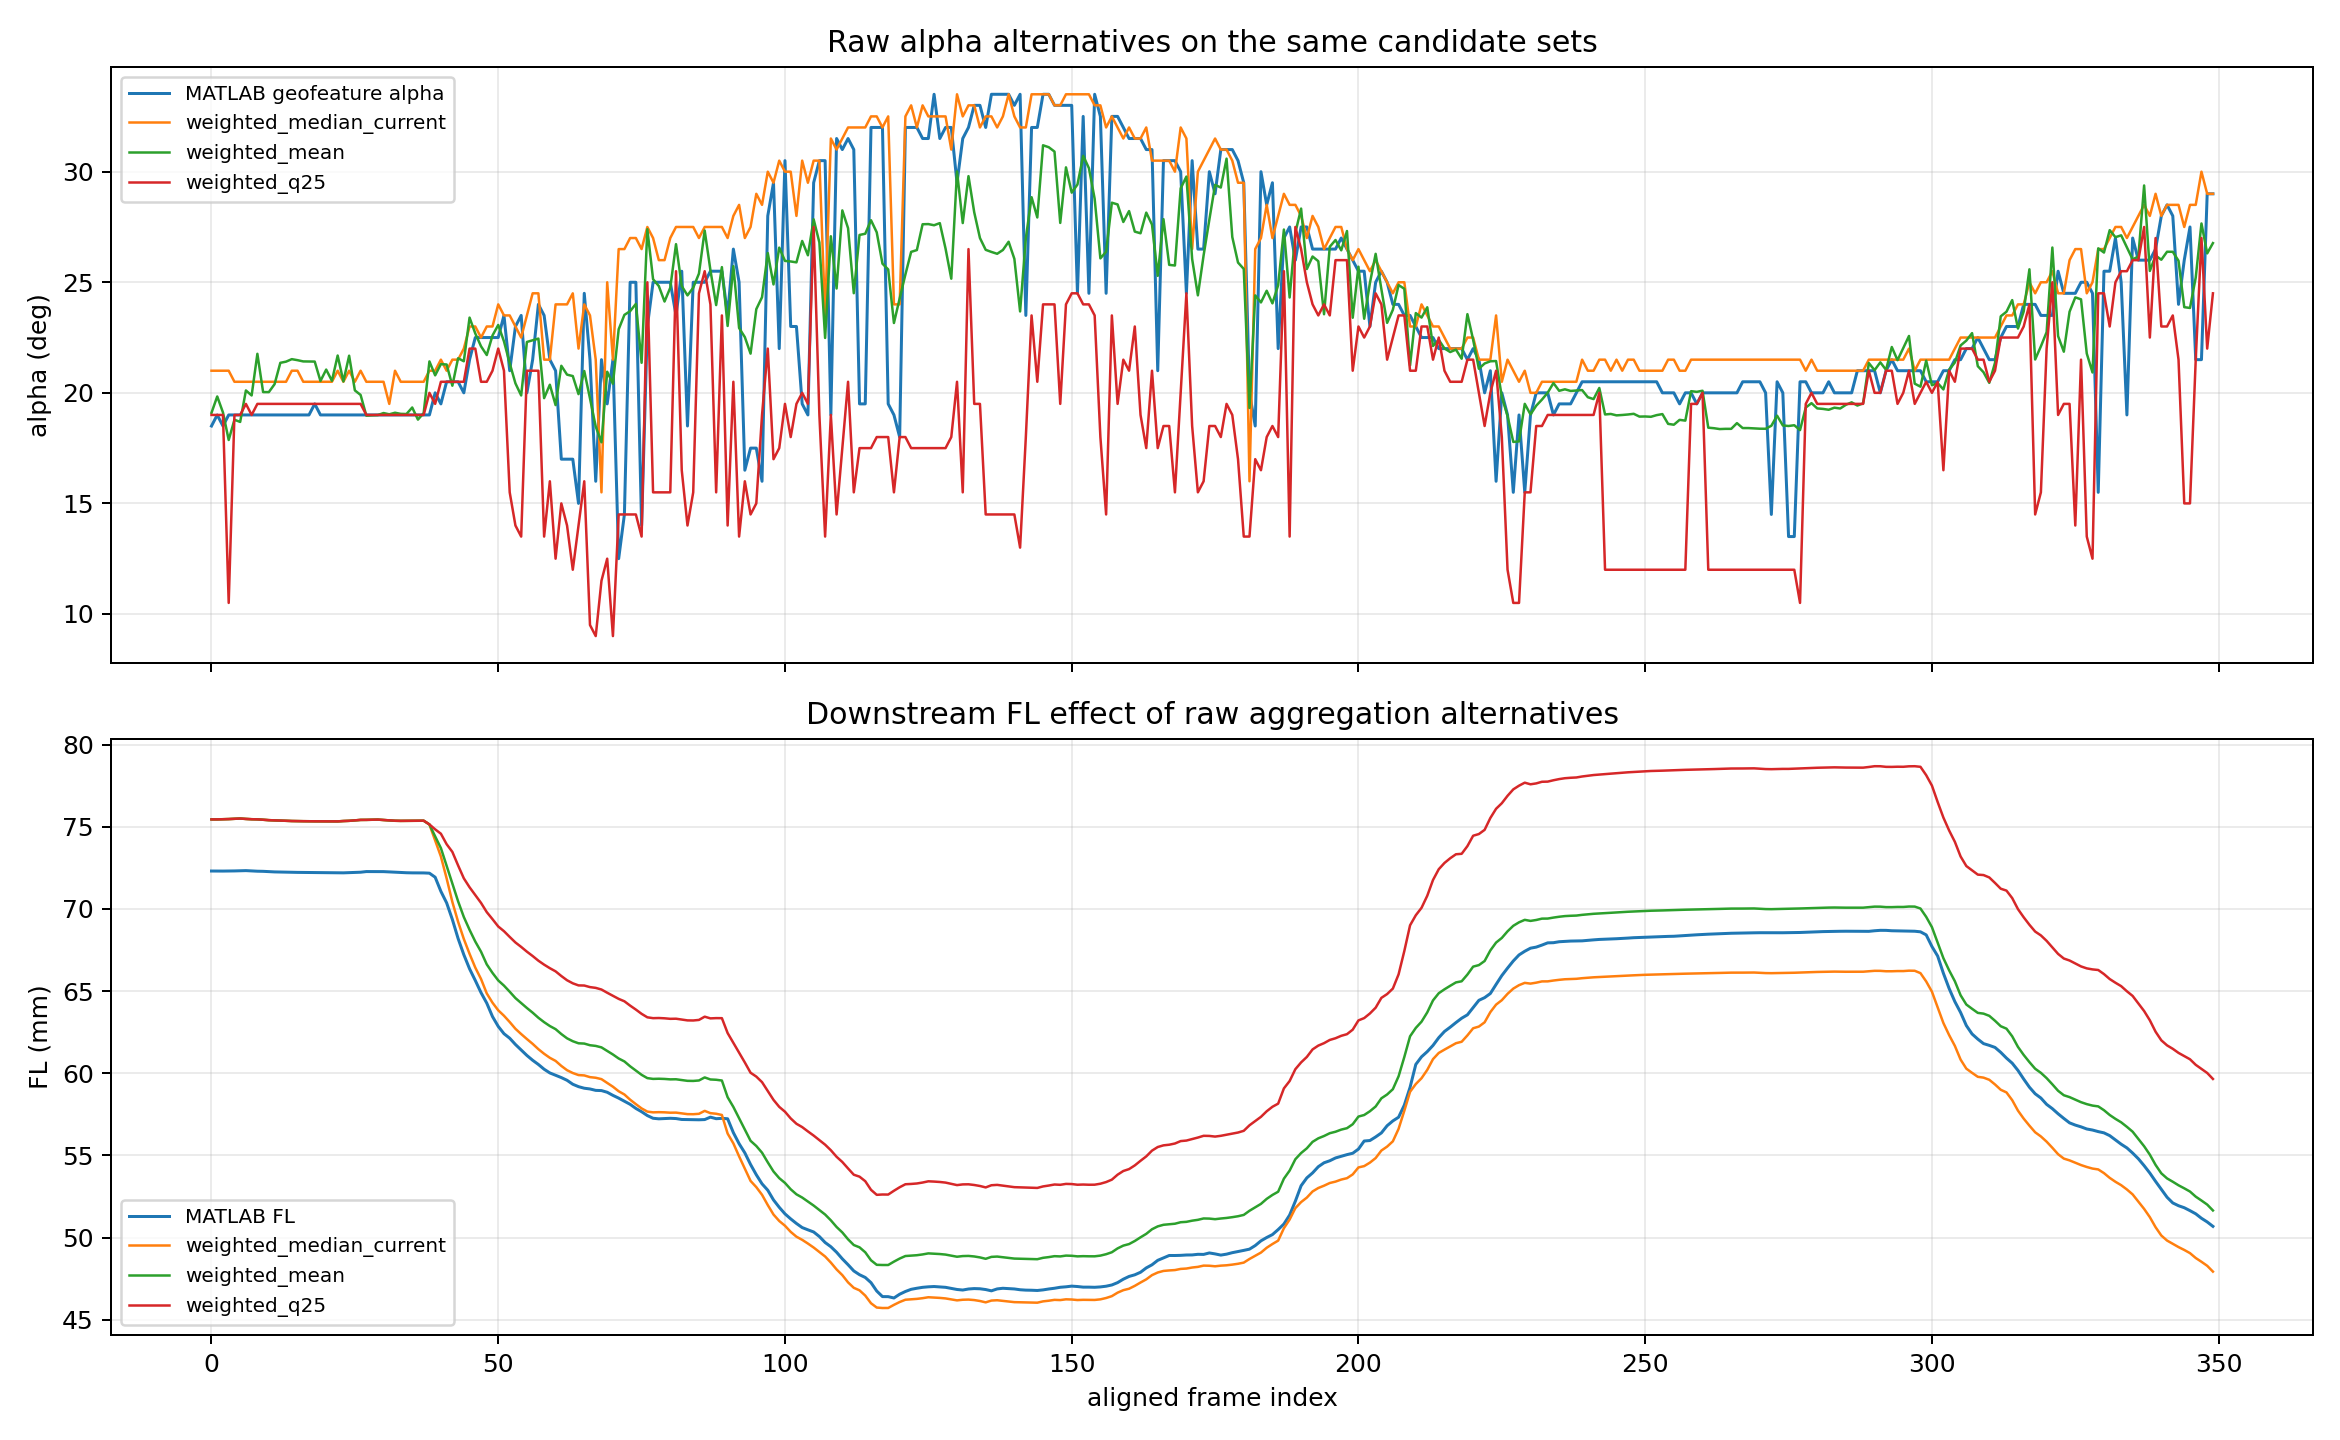

In [5]:
display(Image(filename=str(OUT / 'aggregation_alternative_summary.png')))
display(Image(filename=str(OUT / 'aggregation_alternative_traces.png')))